<a href="https://colab.research.google.com/github/miftahuljana/Prediksi-Kelulusan-Mahasiswa-Menggunakan-Algoritma-Naive-Bayes_ML/blob/main/Copy_of_Untitled17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Pengumpulan Data (Data Collection)**

Tahap awal mengumpulkan dataset.

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [7]:
import pandas as pd

df = pd.read_csv('data akademik.csv')
print(df.head())

                    Nama        Nim   Program studi Jenis kelamin  \
0  Muhammad Ryian Dzuhri  F1G123029   Ilmu Komputer     Laki-laki   
1  Gusti Krisna Pranata   F1G123019  Ilmu Komputer      Laki-laki   
2  Wa Ode Zahra Ramadani  F1G123016   Ilmu Komputer     Perempuan   
3     Iqra Fauzan Akbar   F1G123020  Ilmu Komputer      Laki-laki   
4          Isranofrianti  F1G123007   Ilmu komputer     Perempuan   

   IPK Semester 1  IPK Semester 2  IPK Semester 3  IPK Semester 4  \
0            3.59            3.64            3.63            4.00   
1            3.86            3.73            3.63            3.88   
2            3.59            3.59            3.30            3.75   
3            3.65            3.59            3.39            3.88   
4            3.34            3.50            3.75            3.75   

   IPK Semester 5 Jumlah SKS Lulus  Kehadiran (contoh 50%)  \
0            3.67              110                      90   
1            3.73              114            

**2. Pemahaman Data (Data Understanding)**

Data understanding (pemahaman data) adalah salah satu fase awal dalam alur kerja Machine Learning (ML) yang bertujuan untuk memahami isi, struktur, kualitas, dan karakteristik dataset sebelum dilakukan pengolahan lebih lanjut.

Tahap ini sangat penting karena model yang baik sangat bergantung pada kualitas dan pemahaman data yang digunakan.

Melihat struktur dan isi data

In [8]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Nama                    228 non-null    object 
 1   Nim                     227 non-null    object 
 2   Program studi           228 non-null    object 
 3   Jenis kelamin           228 non-null    object 
 4   IPK Semester 1          228 non-null    float64
 5   IPK Semester 2          228 non-null    float64
 6   IPK Semester 3          228 non-null    float64
 7   IPK Semester 4          228 non-null    float64
 8   IPK Semester 5          228 non-null    float64
 9   Jumlah SKS Lulus        228 non-null    object 
 10  Kehadiran (contoh 50%)  228 non-null    int64  
 11  Aktivitas organisasi    228 non-null    object 
dtypes: float64(5), int64(1), object(6)
memory usage: 21.5+ KB
None
       IPK Semester 1  IPK Semester 2  IPK Semester 3  IPK Semester 4  \
count      2

**3. EDA (Exploratory Data Analysis)**

EDA adalah proses analisis awal data untuk:

- memahami pola

- melihat distribusi

- menemukan hubungan antar variabel

- mendeteksi masalah (missing value, outlier, dll)

EDA biasanya dilakukan sebelum membuat model Machine Learning agar kita tahu data kita “sehat” atau tidak.

**a. Histogram**

Histogram adalah grafik yang menunjukkan distribusi frekuensi data numerik.

👉 Artinya:

- Menunjukkan seberapa sering nilai tertentu muncul

- Membantu melihat bentuk distribusi data

🔎 Fungsi:

- Mengetahui apakah data normal (bell shape)

- Melihat skewness (condong kiri/kanan)

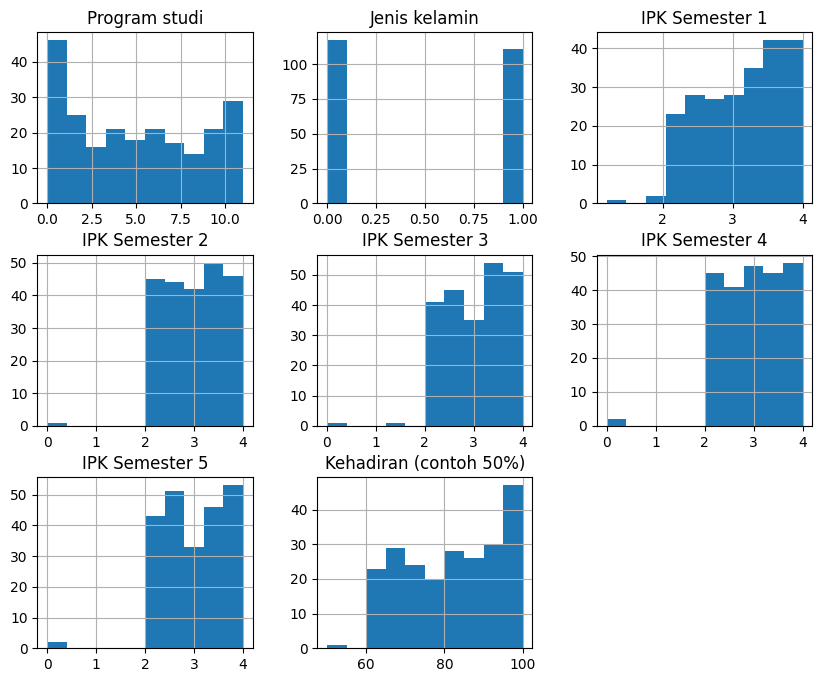

In [14]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.show()

**b. Boxplot**

Boxplot adalah grafik yang menunjukkan ringkasan statistik data dan outlier.

Isi boxplot:

- Min (nilai minimum)

- Q1 (kuartil 1)

- Median (nilai tengah)

- Q3 (kuartil 3)

- Max (nilai maksimum)

- Outlier (titik ekstrem)

🔎 Fungsi:

- Mendeteksi outlier

- Melihat penyebaran data

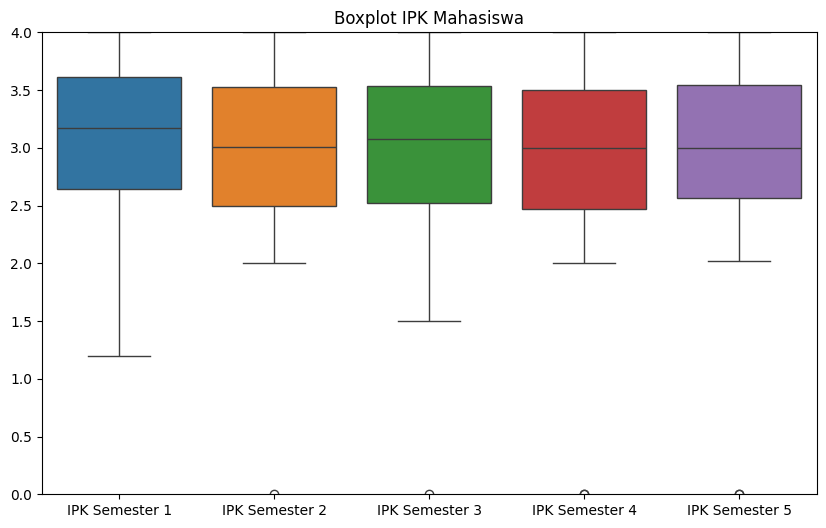

In [16]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['IPK Semester 1', 'IPK Semester 2', 'IPK Semester 3',
                     'IPK Semester 4', 'IPK Semester 5']])

plt.ylim(0, 4)
plt.title('Boxplot IPK Mahasiswa')
plt.show()

**c. Heatmap (Correlation)**

Heatmap adalah visualisasi berbentuk warna untuk menunjukkan korelasi antar fitur.

Biasanya menggunakan matriks korelasi.

Nilai korelasi:

- +1 → sangat berhubungan

- 0 → tidak berhubungan

- -1 → berlawanan

🔎 Fungsi:

Mengetahui fitur yang saling berhubungan

Memilih fitur penting untuk model

Menghindari fitur yang terlalu mirip (redundan)

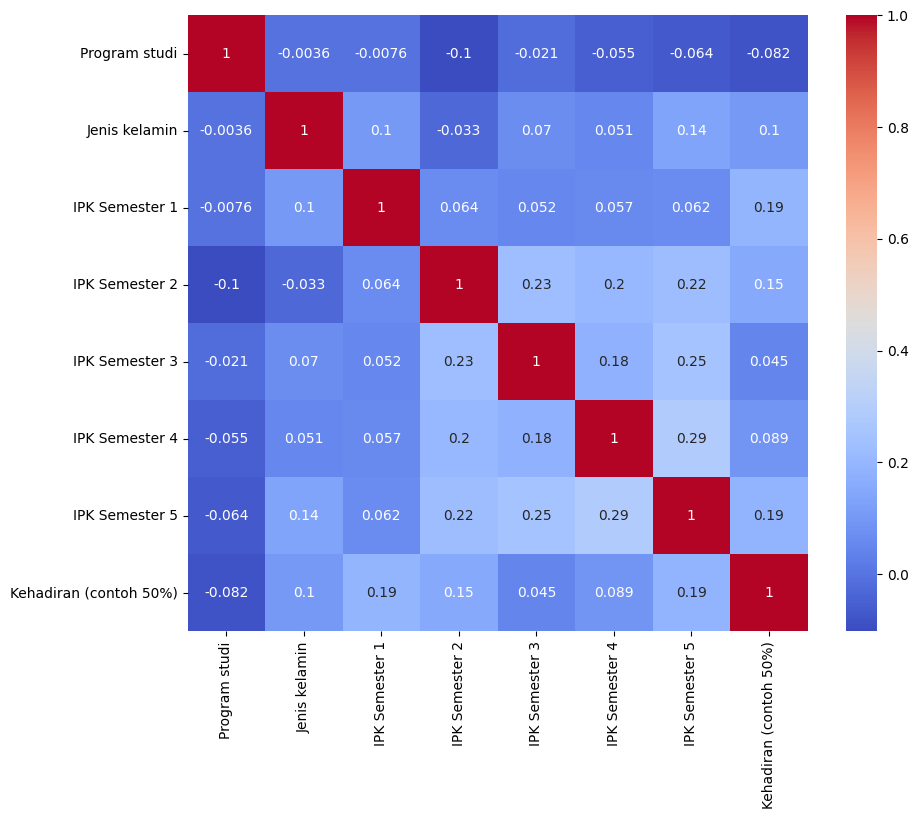

In [17]:
import numpy as np

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()

**d. Pairplot (opsional)**

Pairplot adalah grafik yang menampilkan hubungan antar semua pasangan fitur dalam dataset.

Isi pairplot:

- Scatter plot antar fitur

- Distribusi tiap fitur (di diagonal)

🔎 Fungsi:

- Melihat pola hubungan antar variabel

- Melihat pemisahan kelas (klasifikasi)

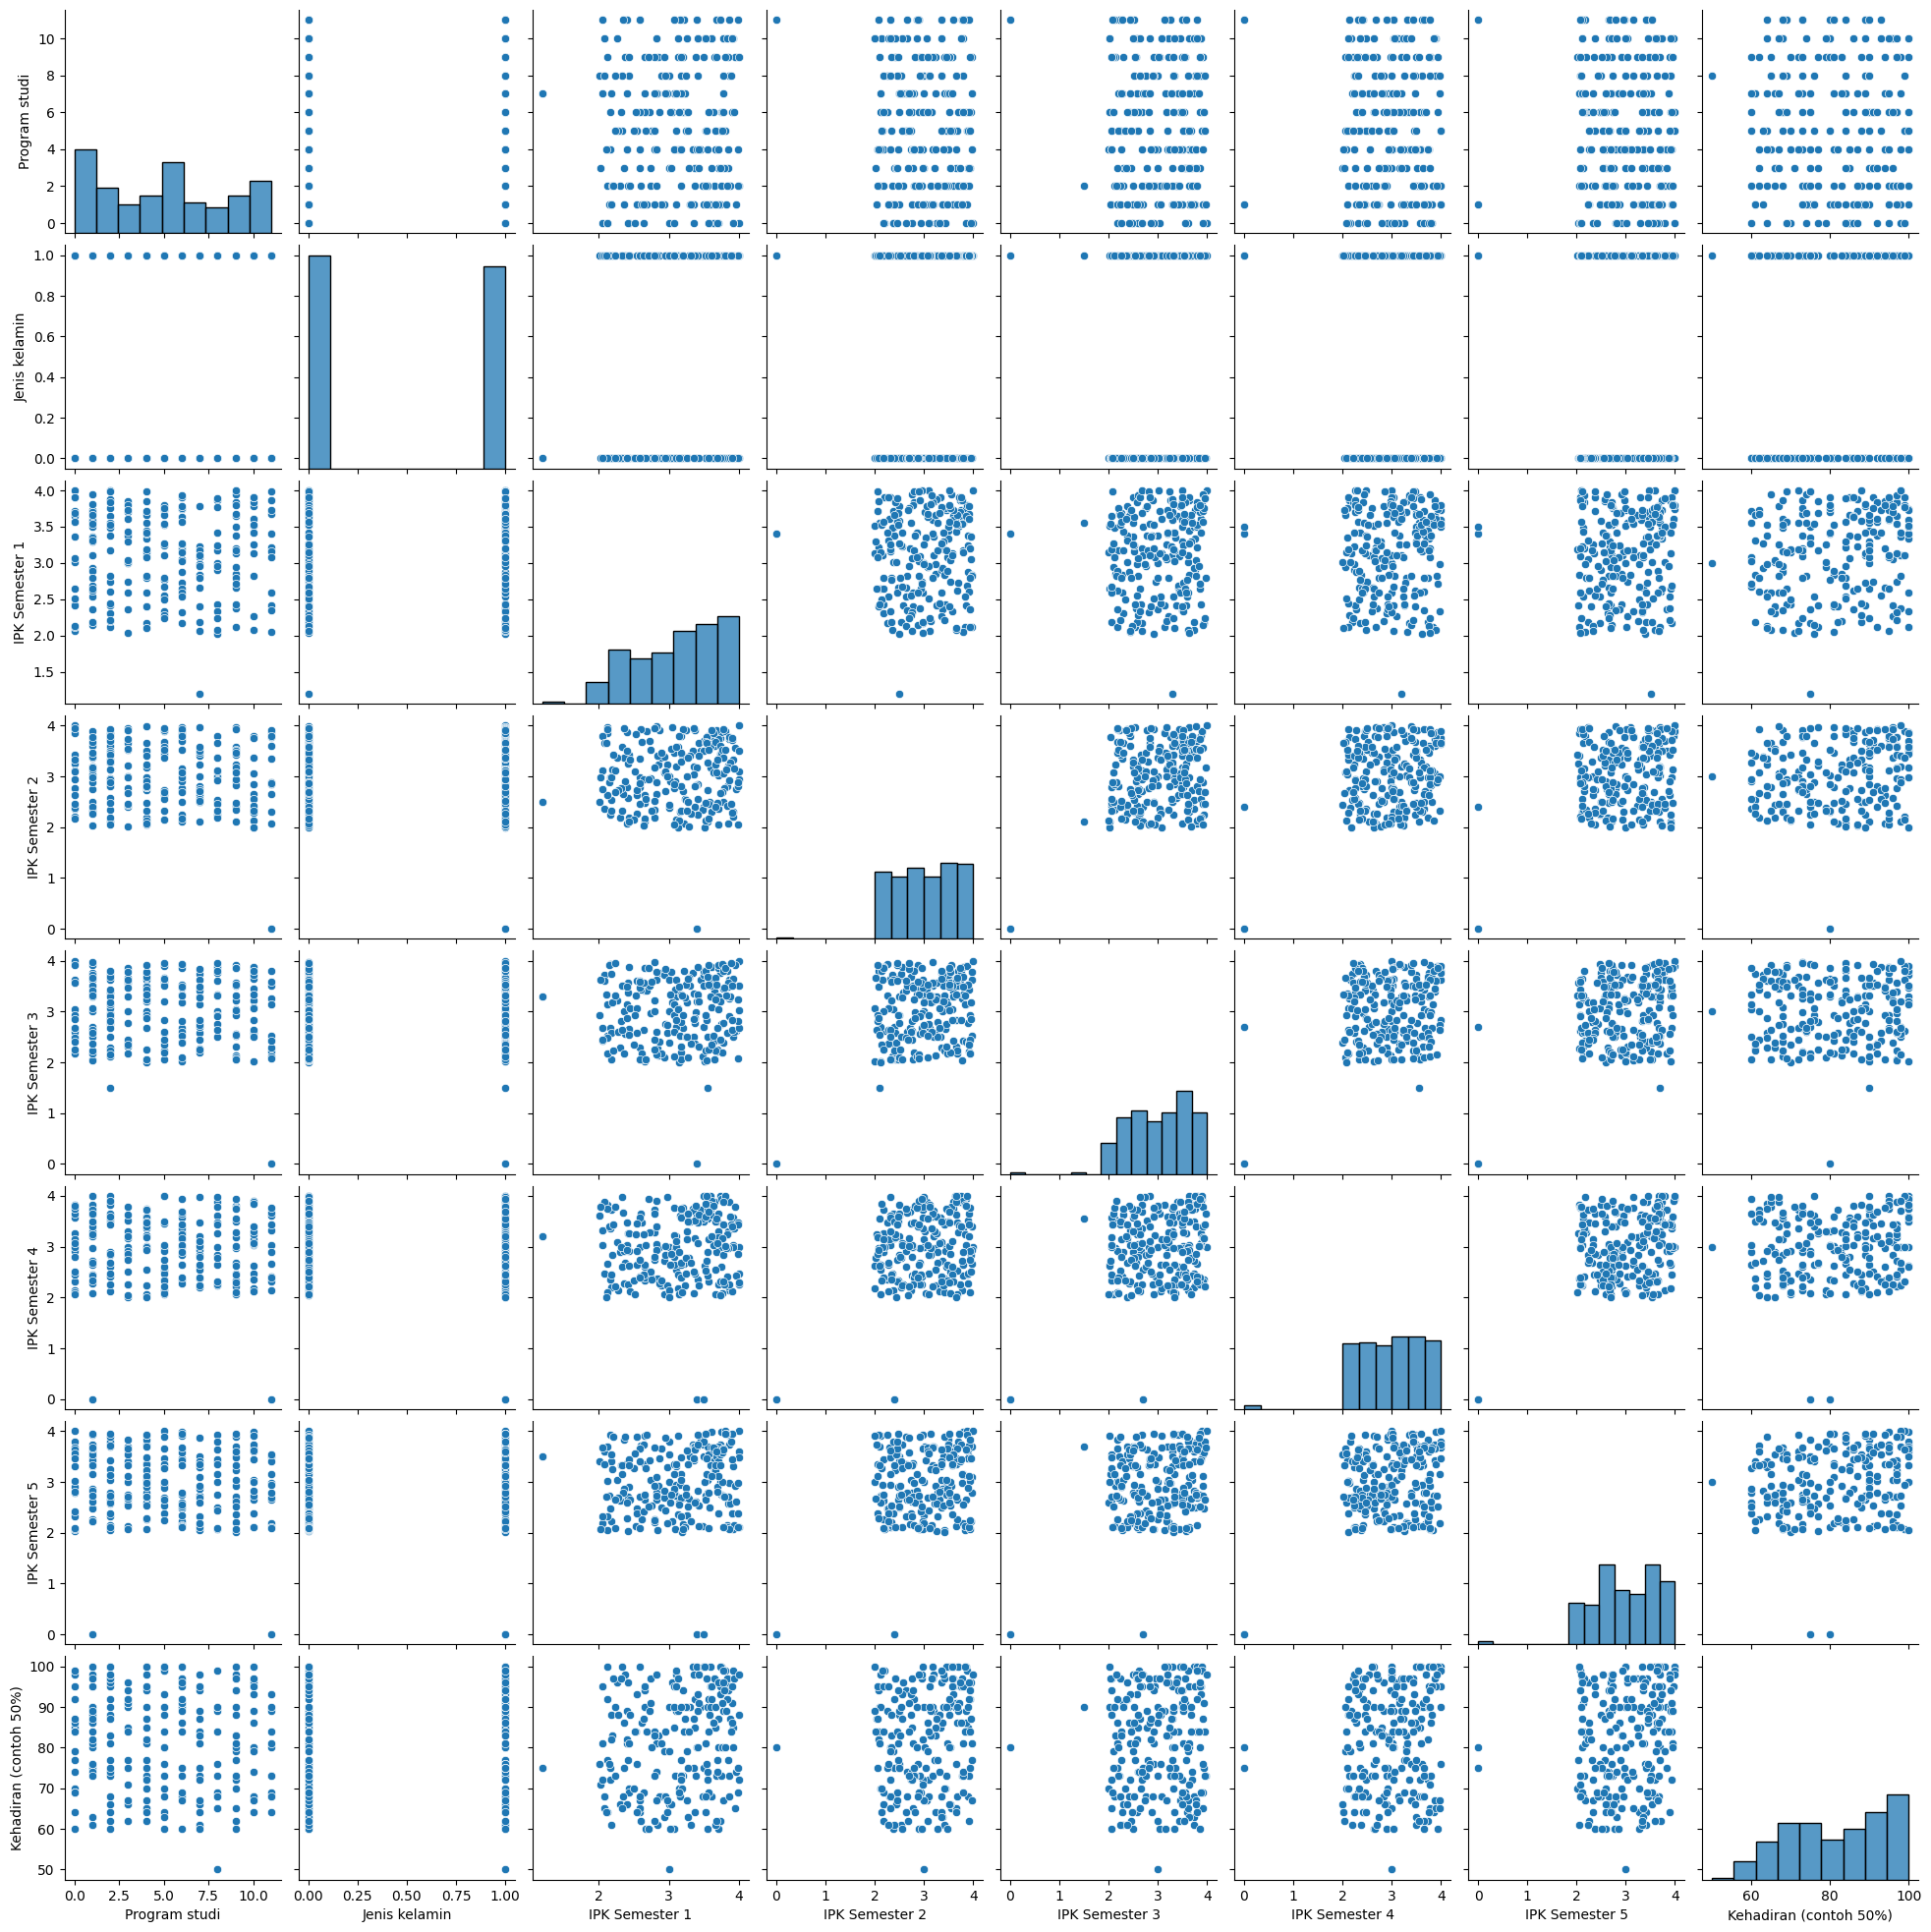

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df)
plt.show()

**4. Data Preprocessing**

Data preprocessing adalah tahap membersihkan dan menyiapkan data sebelum digunakan untuk melatih model ML.

Tujuannya:

- Membuat data lebih rapi dan konsisten

- Menghindari error saat training

- Meningkatkan akurasi model

1. Mengatasi Missing Value

Missing value adalah data yang kosong / tidak terisi (NaN).

🔎 Cara mengatasi:

- Menghapus data

👉 Digunakan jika jumlah data kosong sedikit

In [20]:
df.dropna()

,Program studi,Jenis kelamin,IPK Semester 1,IPK Semester 2,IPK Semester 3,IPK Semester 4,IPK Semester 5,Jumlah SKS Lulus,Kehadiran (contoh 50%),Aktivitas organisasi
0,1,0,3.59,3.64,3.63,4.00,3.67,110,90,Tidak
1,2,0,3.86,3.73,3.63,3.88,3.73,114,95,Tidak
2,1,1,3.59,3.59,3.30,3.75,3.59,155,100,Tidak
3,2,0,3.65,3.59,3.39,3.88,3.43,120,97,Tidak
4,4,1,3.34,3.50,3.75,3.75,3.73,137,100,Tidak
...,...,...,...,...,...,...,...,...,...,...
223,0,0,3.69,3.32,2.67,3.06,2.81,81,74,Ya
224,10,0,3.90,3.76,2.83,3.40,3.45,92,86,Ya
225,0,0,3.36,3.95,2.85,2.50,3.46,110,87,Ya
226,5,0,2.24,2.69,3.95,2.21,2.65,108,73,Ya


b. Mengisi data (imputasi)

Jangan biarkan data kosong → model tidak bisa membaca NaN

Numerik:

In [71]:
# Numerik
df['IPK Semester 1'].fillna(df['IPK Semester 1'].mean(), inplace=True)

/tmp/ipykernel_8535/1941772772.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['IPK Semester 1'].fillna(df['IPK Semester 1'].mean(), inplace=True)


In [72]:
# Kategorikal
df['Jenis kelamin'] = df['Jenis kelamin'].fillna(df['Jenis kelamin'].mode()[0])

#Digunakan jika tidak ingin kehilangan data

In [73]:
df.fillna(df.mean(numeric_only=True), inplace=True)

2. Encoding (Mengubah Data Kategorikal)

Model ML hanya bisa membaca angka, jadi data seperti:

- "Laki-laki"
- "Perempuan"
- "Lulus"

harus diubah menjadi angka.

In [74]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Jenis kelamin'] = le.fit_transform(df['Jenis kelamin'])

**c. Feature & Target**

Dalam ML, data dibagi menjadi:

✅ Feature (X)

- Variabel input (penyebab)

- Contoh: IPK Semester 1–5, Kehadiran

✅ Target (y)

- Variabel output (yang diprediksi)

- Contoh: Status (Lulus / Tidak)

In [88]:
X = df[['IPK Semester 1', 'IPK Semester 2', 'IPK Semester 3',
        'IPK Semester 4', 'IPK Semester 5',
        'Jumlah SKS Lulus', 'Kehadiran']]

y = df['Status']

In [76]:
# Encoding target
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

**5. Split Data (Training & Testing)**

Split data adalah proses membagi dataset menjadi:

- Data training → untuk melatih model

- Data testing → untuk menguji model

🎯 Tujuan:

- Mengetahui apakah model bisa bekerja pada data baru

- Menghindari overfitting (model hafal data)

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Penjelasan:

- test_size=0.2 → 20% data untuk testing

- random_state=42 → agar hasil tetap sama setiap dijalankan

**6. Model Training**

Model training adalah proses di mana algoritma belajar dari data training.

🎯 Tujuan:

Menemukan pola hubungan antara fitur (X) dan target (y)

In [91]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [92]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

In [93]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

In [94]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model
nb = GaussianNB()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

# Training
nb.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier()

**7. Prediksi**

In [95]:
y_pred = model.predict(X_test)

In [96]:
y_pred_nb = nb.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

**8. Evaluasi Model**

**a. Akurasi**

In [109]:
from sklearn.metrics import accuracy_score

print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.9130434782608695


In [98]:
from sklearn.metrics import accuracy_score

acc_nb = accuracy_score(y_test, y_pred_nb)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Naive Bayes:", acc_nb)
print("Decision Tree:", acc_dt)
print("Random Forest:", acc_rf)

Naive Bayes: 0.9130434782608695
Decision Tree: 0.8043478260869565
Random Forest: 0.8913043478260869


**b. Confusion Matrix**

In [99]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_nb)
print(cm)

[[16  3]
 [ 1 26]]


**c. Classification Report**

In [100]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.84      0.89        19
           1       0.90      0.96      0.93        27

    accuracy                           0.91        46
   macro avg       0.92      0.90      0.91        46
weighted avg       0.91      0.91      0.91        46



👉 Penjelasan:

Accuracy → seberapa benar model

Precision → ketepatan prediksi positif

Recall → kemampuan menangkap data positif

F1-score → keseimbangan precision & recall

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
df['Jumlah SKS Lulus'] = pd.to_numeric(df['Jumlah SKS Lulus'], errors='coerce').fillna(0).astype(int)
df['Status'] = df.apply(lambda row:
    1 if (row['IPK Semester 5'] >= 3.0 and
          row['Jumlah SKS Lulus'] >= 144)
    else 0, axis=1)

In [ ]:
df['Aktivitas organisasi_encoded'] = df['Aktivitas organisasi'].map({'Tidak': 0, 'Aktif': 1})
# Fill any potential NaNs in the encoded column, assuming 0 as a default if other values exist
df['Aktivitas organisasi_encoded'] = df['Aktivitas organisasi_encoded'].fillna(0)

X = df[['IPK Semester 5', 'Jumlah SKS Lulus',
        'Kehadiran (contoh 50%)', 'Aktivitas organisasi_encoded']]

y = df['Status']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X = df[['IPK Semester 5', 'Kehadiran (contoh 50%)', 'Jumlah SKS Lulus']]
y = df['Status']

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
X = df.drop(['Status', 'Aktivitas organisasi'], axis=1)
y = df['Status']

In [ ]:
df['Status'] = df.apply(lambda row:
    1 if (row['IPK Semester 5'] >= 3.0 and
          row['Jumlah SKS Lulus'] >= 144 and
          row['Kehadiran (contoh 50%)'] >= 75)
    else 0, axis=1)

In [ ]:
print(df.columns)

In [ ]:
df = df.drop(columns=['Aktivitas organisasi_encoded'])

In [10]:
df = df.drop(['Nama', 'Nim'], axis=1)

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Jenis kelamin'] = le.fit_transform(df['Jenis kelamin'])
df['Program studi'] = le.fit_transform(df['Program studi'])

In [ ]:
print("Naive Bayes:", accuracy)
print("Decision Tree:", acc_dt)
print("Random Forest:", acc_rf)

In [ ]:
nb = GaussianNB()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

In [ ]:
nb.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

In [ ]:
y_pred_nb = nb.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [ ]:
acc_nb = accuracy_score(y_test, y_pred_nb)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)

In [ ]:
print("=== Perbandingan Akurasi Algoritma ===")
print("Naive Bayes     :", acc_nb)
print("Decision Tree   :", acc_dt)
print("Random Forest   :", acc_rf)

In [101]:
print("\n=== Naive Bayes ===")
print(classification_report(y_test, y_pred_nb))

print("\n=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt))

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))


=== Naive Bayes ===
              precision    recall  f1-score   support

           0       0.94      0.84      0.89        19
           1       0.90      0.96      0.93        27

    accuracy                           0.91        46
   macro avg       0.92      0.90      0.91        46
weighted avg       0.91      0.91      0.91        46


=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.71      0.89      0.79        19
           1       0.91      0.74      0.82        27

    accuracy                           0.80        46
   macro avg       0.81      0.82      0.80        46
weighted avg       0.83      0.80      0.81        46


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87        19
           1       0.92      0.89      0.91        27

    accuracy                           0.89        46
   macro avg       0.89      0.89      0.89        46
weighte

In [103]:
df['Status'] = df['Rata_IPK'].apply(
    lambda x: 'Lulus' if x >= 2.5 else 'Tidak Lulus'
)

In [104]:
df['Status'] = df['Rata_IPK'].apply(
    lambda x: 'Lulus' if x >= 3.0 else 'Tidak Lulus'
)

In [105]:
print(df['Status'].value_counts())

Status
Tidak Lulus    117
Lulus          111
Name: count, dtype: int64


In [81]:
df['Jumlah SKS Lulus'] = df['Jumlah SKS Lulus'].str.replace('sks', '').str.strip().astype(int)

In [106]:
print(df['Jumlah SKS Lulus'].head())
print(df.dtypes)

0    110
1    114
2    155
3    120
4    137
Name: Jumlah SKS Lulus, dtype: int64
Program studi         int64
Jenis kelamin         int64
IPK Semester 1      float64
IPK Semester 2      float64
IPK Semester 3      float64
IPK Semester 4      float64
IPK Semester 5      float64
Jumlah SKS Lulus      int64
Kehadiran             int64
Rata_IPK            float64
Status               object
dtype: object


In [107]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'])

In [108]:
print(df['Status'].value_counts())

Status
1    117
0    111
Name: count, dtype: int64
